In [8]:
!python3 -m pip install --upgrade pip
!pip install pdb-tools rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 4.0 MB/s  0:00:08m0:00:0100:01m


In [2]:
!apt update -y

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1942 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3297 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3617 kB]m
Get:9 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [48.5 kB]33m
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [5340 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1576 kB]m
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/multi

In [3]:
!apt install -y libxext6 libxrender1 libgl1 libgl1-mesa-dri libglu1-mesa

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libbsd0 libdrm-amdgpu1 libdrm-common libdrm-intel1 libdrm-nouveau2
  libdrm-radeon1 libdrm2 libedit2 libgl1-amber-dri libglapi-mesa libglvnd0
  libglx-mesa0 libglx0 libllvm15 libmd0 libopengl0 libpciaccess0
  libsensors-config libsensors5 libx11-6 libx11-data libx11-xcb1 libxau6
  libxcb-dri2-0 libxcb-dri3-0 libxcb-glx0 libxcb-present0 libxcb-randr0
  libxcb-shm0 libxcb-sync1 libxcb-xfixes0 libxcb1 libxdmcp6 libxfixes3
  libxshmfence1 libxxf86vm1
Suggested packages:
  pciutils lm-sensors
The following NEW packages will be installed:
  libbsd0 libdrm-amdgpu1 libdrm-common libdrm-intel1 libdrm-nouveau2
  libdrm-radeon1 libdrm2 libedit2 libgl1 libgl1-amber-dri libgl1-mesa-dri
  libglapi-mesa libglu1-mesa libglvnd0 libglx-mesa0 libglx0 libllvm15 libmd0
  libopengl0 libpciaccess0 libsensors-config libsensors5 libx11-6 libx11-data
  libx11-xc

In [4]:
!pip install openbabel-wheel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 3.7 MB/s  0:00:04m0:00:0100:01


In [14]:
!obabel Ligand_Pubchem_Data/EnniatinA/Conformer3D_COMPOUND_CID_57339252.sdf -O Ligand_Pubchem_Data/EnniantinA/EnniatinA.pdb


1 molecule converted


In [15]:
!obabel Ligand_Pubchem_Data/EnniatinA1/Conformer3D_COMPOUND_CID_57339253.sdf -O Ligand_Pubchem_Data/EnniantinA1/EnniatinA1.pdb


1 molecule converted


In [16]:
!obabel Ligand_Pubchem_Data/EnniatinB/Conformer3D_COMPOUND_CID_164754.sdf -O Ligand_Pubchem_Data/EnniantinB/EnniatinB.pdb


1 molecule converted


In [17]:
!obabel Ligand_Pubchem_Data/EnniatinB1/Conformer3D_COMPOUND_CID_11262300.sdf -O Ligand_Pubchem_Data/EnniantinB1/EnniatinB1.pdb

1 molecule converted


In [20]:
!obabel RCSB_Ligand/Warfarin/RWF_ideal.sdf -O RCSB_Ligand/Warfarin/RWF.pdb

1 molecule converted


In [22]:
!obabel RCSB_Ligand/Ibuprofen/IBP_ideal.sdf -O RCSB_Ligand/Ibuprofen/IBP.pdb

1 molecule converted


In [4]:
!obabel Ligand_Pubchem_Data/Sucrose/Conformer3D_COMPOUND_CID_5988.sdf -O Ligand_Pubchem_Data/Sucrose/SUC.pdb

1 molecule converted


In [1]:
!obabel RCSB_Ligand/Warfarin/RWF_ideal.sdf -O RCSB_Ligand/Warfarin/RWF_2d.sdf --gen2d

*** Open Babel Error  in OpenAndSetFormat
  Cannot open RCSB_Ligand/Sucrose/Conformer3D_COMPOUND_CID_5988.sdf
0 molecules converted


In [24]:
!obabel RCSB_Ligand/Ibuprofen/IBP_ideal.sdf -O RCSB_Ligand/Ibuprofen/IBP_2d.sdf --gen2d

1 molecule converted


In [6]:
!obabel Ligand_Pubchem_Data/Sucrose/SUC.pdb -O Ligand_Pubchem_Data/Sucrose/SUC_2d.sdf --gen2d

1 molecule converted


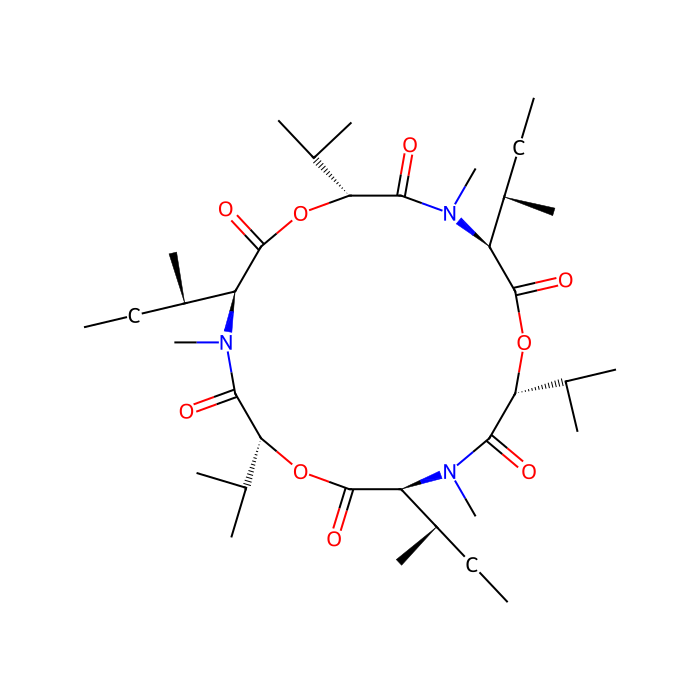

In [43]:
from rdkit import Chem
from rdkit.Chem import rdDepictor, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image as IPImage

mol = Chem.MolFromMolFile("Ligand_Pubchem_Data/EnniatinA/Structure2D_COMPOUND_CID_57339252.sdf")          # or Chem.MolFromMolFile("file.sdf")
mol = Chem.RemoveHs(mol)

try:
    m3 = Chem.AddHs(mol); AllChem.EmbedMolecule(m3,randomSeed=42); AllChem.MMFFOptimizeMolecule(m3)
    rdDepictor.Compute2DCoords(m3, canonOrient=False, forceRDKit=True); mol = Chem.RemoveHs(m3)
except:
    rdDepictor.Compute2DCoords(mol, canonOrient=False, forceRDKit=True)

rdMolDraw2D.PrepareMolForDrawing(mol, kekulize=True, addChiralHs=False, wedgeBonds=True, forceCoords=True)
d = rdMolDraw2D.MolDraw2DCairo(700,700); opts = d.drawOptions(); opts.fixedBondLength=45; opts.padding=0.12
rdMolDraw2D.PrepareAndDrawMolecule(d,mol); d.FinishDrawing(); open("clean.png","wb").write(d.GetDrawingText())
png = d.GetDrawingText()
display(IPImage(data=png))


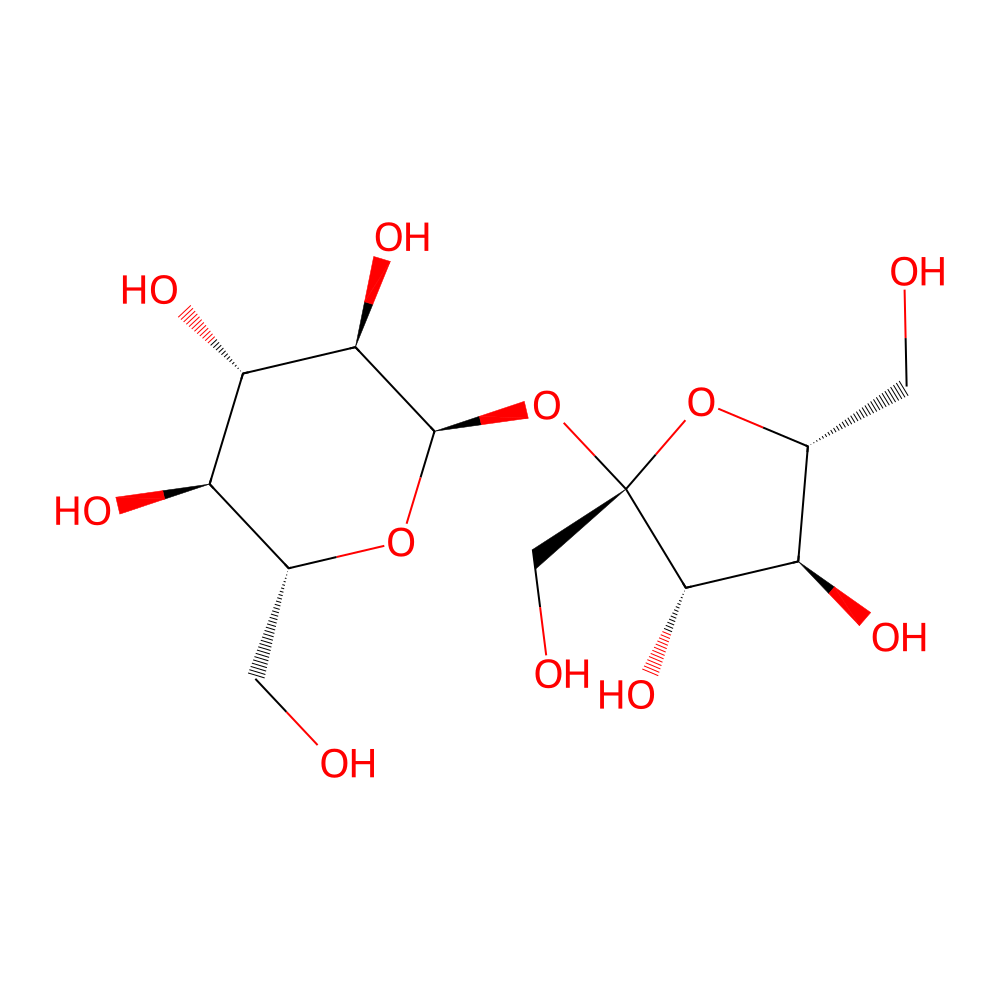

In [21]:
from rdkit import Chem
from rdkit.Chem import rdDepictor, Draw

mol = Chem.MolFromSmiles("C([C@@H]1[C@H]([C@@H]([C@H]([C@H](O1)O[C@]2([C@H]([C@@H]([C@H](O2)CO)O)O)CO)O)O)O)O")  # example
#mol = Chem.RemoveHs(mol)            # remove explicit Hs for layout
rdDepictor.Compute2DCoords(mol)    # generate 2D coords
img = Draw.MolToImage(mol, size=(1000,1000))
display(img)
img.save("noHs.png")

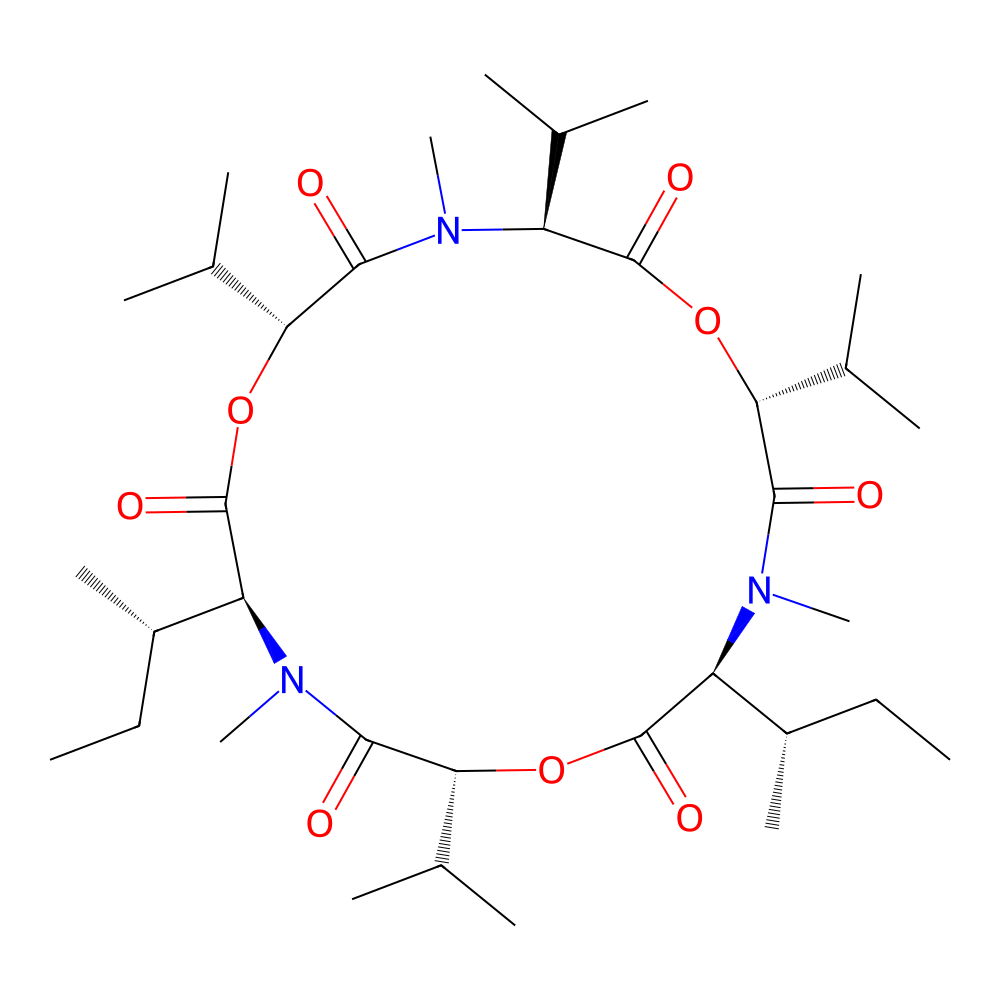

In [18]:
mol = Chem.MolFromSmiles("CC[C@H](C)[C@H]1C(=O)O[C@@H](C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H](C(=O)O[C@@H](C(=O)N1C)C(C)C)[C@@H](C)CC)C)C(C)C)C(C)C)C)C(C)C")  # example
#mol = Chem.RemoveHs(mol)            # remove explicit Hs for layout
rdDepictor.Compute2DCoords(mol)    # generate 2D coords
img = Draw.MolToImage(mol, size=(1000,1000))
display(img)
img.save("noHs.png")

In [22]:
# install via: conda install -c conda-forge openbabel python-openbabel
import pybel
mol = next(pybel.readfile("sdf","molecules.sdf"))
mol.make2D()
mol.draw(show=False, filename="ob_mol.png")   # produces PNG


ModuleNotFoundError: No module named 'pybel'